# Clustering su Componenti Principali (PCA-Based)
Analisi di clustering su spazio ridotto tramite PCA. Questo approccio riduce la dimensionalità dei dati preservando la varianza principale e facilita l'interpretazione dei profili psicologici latenti.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score
from sklearn.ensemble import RandomForestClassifier
import warnings
import sqlite3
import os
import json
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Caricamento Dati

In [3]:
# pip install nbconvert
import subprocess
import sys

# Esegui setup_raw_data.py
result_setup = subprocess.run([sys.executable, '../script/setup_raw_data.py'], 
                              capture_output=True, text=True)
print(result_setup.stdout)
if result_setup.stderr:
    print("STDERR:", result_setup.stderr)

# Esegui notebook pulizia con nbconvert
result_clean = subprocess.run([
    sys.executable, '-m', 'nbconvert', 
    '--to', 'notebook', 
    '--execute', 
    '--ExecutePreprocessor.timeout=600',
    '../notebook/pulizia.ipynb'
], capture_output=True, text=True, cwd='.')

print(result_clean.stdout)
if result_clean.stderr:
    print("STDERR:", result_clean.stderr)


Creazione tabella raw_data...
Tabella raw_data creata

Credenziali caricate!
Credenziali caricate da: c:\Users\Utente\OneDrive - ITS Tech Talent Factory\Project Work\Project-Work\script\..\local\analisi-ansia-dcecdb75c868.json

Connessione a Google Sheets...
Trovate 170 risposte
Numero colonne: 39

Inizio importazione dati in raw_data...


Importazione completata!
   - Righe inserite: 170
   - Righe saltate: 0

Fine

STDERR: c:\Users\Utente\OneDrive - ITS Tech Talent Factory\Project Work\Project-Work\venv\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.10) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


STDERR: [NbConvertApp] Converting notebook ../notebook/pulizia.ipynb to n

In [4]:
import sys
sys.path.append('..')
from script.connessioni import get_mysql_connection

conn = get_mysql_connection()

# Carica tutti i dati da clean_data in un DataFrame
query = "SELECT * FROM clean_data"
df = pd.read_sql(query, conn)

conn.close()

print(f"Dataset caricato: {df.shape[0]} righe, {df.shape[1]} colonne")
df.head()

Dataset caricato: 148 righe, 37 colonne


,id,email,contesto,età,genere,area_geo,anni_esperienza,Item_1,Item_2,Item_3,...,Item_21,Item_22,Item_23,Item_24,Item_25,Item_26,Item_27,Item_28,Item_29,Item_30
0,1,None,Entrambi,24,Femmina,Nord Italia,5.0,4,5,4,...,5,5,1,1,2,2,4,5,5,Durante gli esami e se devo interagire con gli...
1,2,None,Studio,26,Femmina,Nord Italia,7.0,4,5,3,...,4,1,3,3,5,2,2,2,4,Durante gli esami
2,3,None,Lavoro,26,Maschio,Nord Italia,5.0,3,4,3,...,3,5,1,1,4,2,5,4,5,Interazione con persone (clienti)
3,4,None,Entrambi,26,Femmina,Nord Italia,5.0,2,4,3,...,2,5,3,3,2,3,2,1,3,L’esame
4,5,None,Studio,22,Femmina,Nord Italia,2.0,3,2,3,...,2,2,3,2,4,3,3,2,4,"Durante il tirocinio, quando devo mettere effe..."


## Preparazione dati per PCA

In [5]:
# Estrazione delle 30 variabili Item
item_columns = [f'Item_{i}' for i in range(1, 30)]
X = df[item_columns].copy()

# Rimozione righe con valori mancanti
X = X.dropna()
print(f"Record con feature complete: {len(X)}")
print(f"Variabili: {len(item_columns)}")
print(f"\nStatistiche descrittive:")
display(X.describe())

Record con feature complete: 38
Variabili: 29

Statistiche descrittive:


,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,...,Item_20,Item_21,Item_22,Item_23,Item_24,Item_25,Item_26,Item_27,Item_28,Item_29
count,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.00000,...,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000
mean,3.368421,3.789474,2.973684,3.684211,4.157895,3.394737,3.000000,2.684211,3.078947,2.50000,...,3.421053,2.868421,3.263158,2.789474,2.631579,3.236842,3.394737,3.000000,2.500000,4.105263
std,1.100885,0.934559,1.102499,1.042483,0.973329,0.973694,1.355669,1.254296,1.323010,1.62331,...,1.106042,0.934939,1.349358,1.094406,1.100885,1.383966,1.242044,1.273429,1.310044,0.894109
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,3.000000,3.250000,2.000000,3.000000,4.000000,3.000000,2.000000,2.000000,2.000000,1.00000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.250000,3.000000
50%,3.500000,4.000000,3.000000,4.000000,4.000000,3.500000,3.000000,3.000000,3.000000,2.00000,...,3.000000,3.000000,3.000000,3.000000,2.500000,3.000000,3.500000,3.000000,2.000000,4.000000
75%,4.000000,4.000000,3.000000,4.000000,5.000000,4.000000,4.000000,3.000000,4.000000,4.00000,...,4.000000,3.000000,4.000000,3.750000,3.750000,4.000000,4.000000,4.000000,3.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [6]:
# Standardizzazione dei dati (cruciale per PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Media delle feature standardizzate: {X_scaled.mean(axis=0)[:5]}...")
print(f"Deviazione standard delle feature standardizzate: {X_scaled.std(axis=0)[:5]}...")

Media delle feature standardizzate: [ 1.63611814e-16  2.22044605e-16 -1.32386792e-16  1.08100663e-16
 -5.84327908e-17]...
Deviazione standard delle feature standardizzate: [1. 1. 1. 1. 1.]...


## Analisi PCA

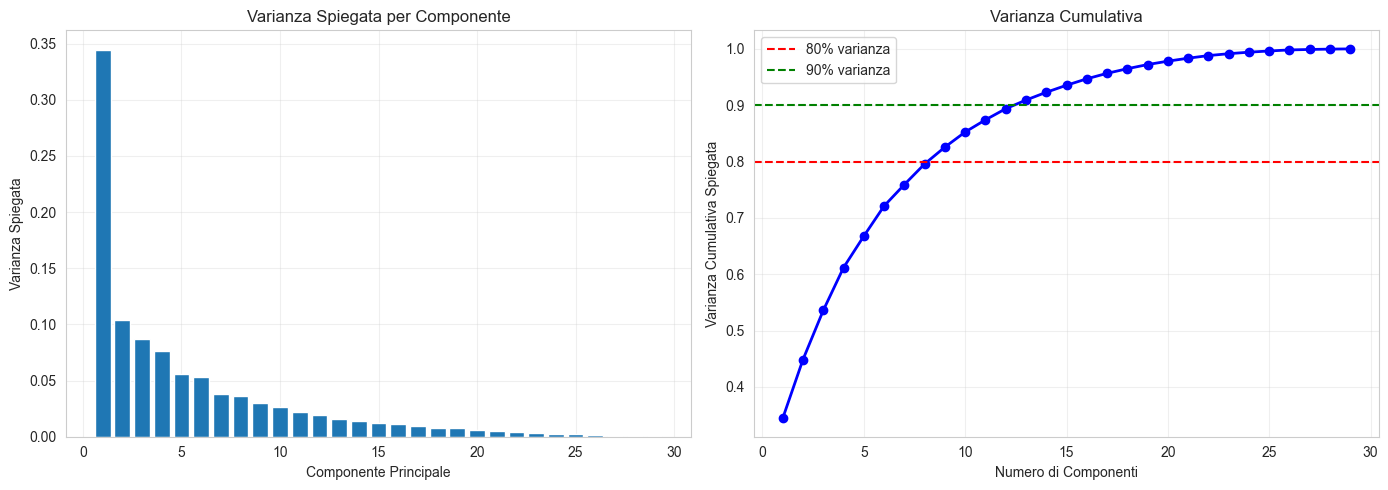


Varianza spiegata per componente:
PC1: 0.3444 (cumulativa: 0.3444)
PC2: 0.1042 (cumulativa: 0.4487)
PC3: 0.0872 (cumulativa: 0.5358)
PC4: 0.0760 (cumulativa: 0.6118)
PC5: 0.0558 (cumulativa: 0.6676)
PC6: 0.0535 (cumulativa: 0.7211)
PC7: 0.0381 (cumulativa: 0.7592)
PC8: 0.0366 (cumulativa: 0.7958)
PC9: 0.0299 (cumulativa: 0.8256)
PC10: 0.0268 (cumulativa: 0.8524)


In [7]:
# Applicazione PCA con tutte le componenti
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

# Calcolo varianza cumulativa
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# Visualizzazione varianza spiegata
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Varianza per componente
ax1.bar(range(1, len(pca_full.explained_variance_ratio_) + 1), 
        pca_full.explained_variance_ratio_)
ax1.set_xlabel('Componente Principale')
ax1.set_ylabel('Varianza Spiegata')
ax1.set_title('Varianza Spiegata per Componente')
ax1.grid(True, alpha=0.3)

# Varianza cumulativa
ax2.plot(range(1, len(cumvar) + 1), cumvar, 'bo-', linewidth=2, markersize=6)
ax2.axhline(y=0.8, color='r', linestyle='--', label='80% varianza')
ax2.axhline(y=0.9, color='g', linestyle='--', label='90% varianza')
ax2.set_xlabel('Numero di Componenti')
ax2.set_ylabel('Varianza Cumulativa Spiegata')
ax2.set_title('Varianza Cumulativa')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nVarianza spiegata per componente:")
for i in range(min(10, len(pca_full.explained_variance_ratio_))):
    print(f"PC{i+1}: {pca_full.explained_variance_ratio_[i]:.4f} (cumulativa: {cumvar[i]:.4f})")

In [8]:
# Determinazione numero ottimale di componenti (80% varianza)
n_components_80 = np.argmax(cumvar >= 0.80) + 1
n_components_90 = np.argmax(cumvar >= 0.90) + 1

print(f"Componenti per 80% varianza: {n_components_80}")
print(f"Componenti per 90% varianza: {n_components_90}")

# Utilizziamo 80% varianza come compromesso tra riduzione e preservazione informazione
n_components = n_components_80
print(f"\nUtilizzeremo {n_components} componenti principali")

Componenti per 80% varianza: 9
Componenti per 90% varianza: 13

Utilizzeremo 9 componenti principali


In [10]:
# PCA con numero ridotto di componenti
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

print(f"Forma dati PCA: {X_pca.shape}")
print(f"Varianza totale spiegata: {pca.explained_variance_ratio_.sum():.4f}")

# Visualizzazione loadings (componenti principali)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loading_df = pd.DataFrame(
    loadings,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=item_columns
)

print("\nLoadings delle prime 2 componenti (top 10 feature):")
print(loading_df[['PC1', 'PC2']].abs().nlargest(10, 'PC1'))

Forma dati PCA: (38, 9)
Varianza totale spiegata: 0.8256

Loadings delle prime 2 componenti (top 10 feature):
              PC1       PC2
Item_15  0.780794  0.165318
Item_20  0.765418  0.048215
Item_9   0.748364  0.063120
Item_27  0.733970  0.119398
Item_6   0.731324  0.037441
Item_1   0.700800  0.197956
Item_8   0.688533  0.501101
Item_28  0.684528  0.113306
Item_12  0.674189  0.555105
Item_11  0.661873  0.205138


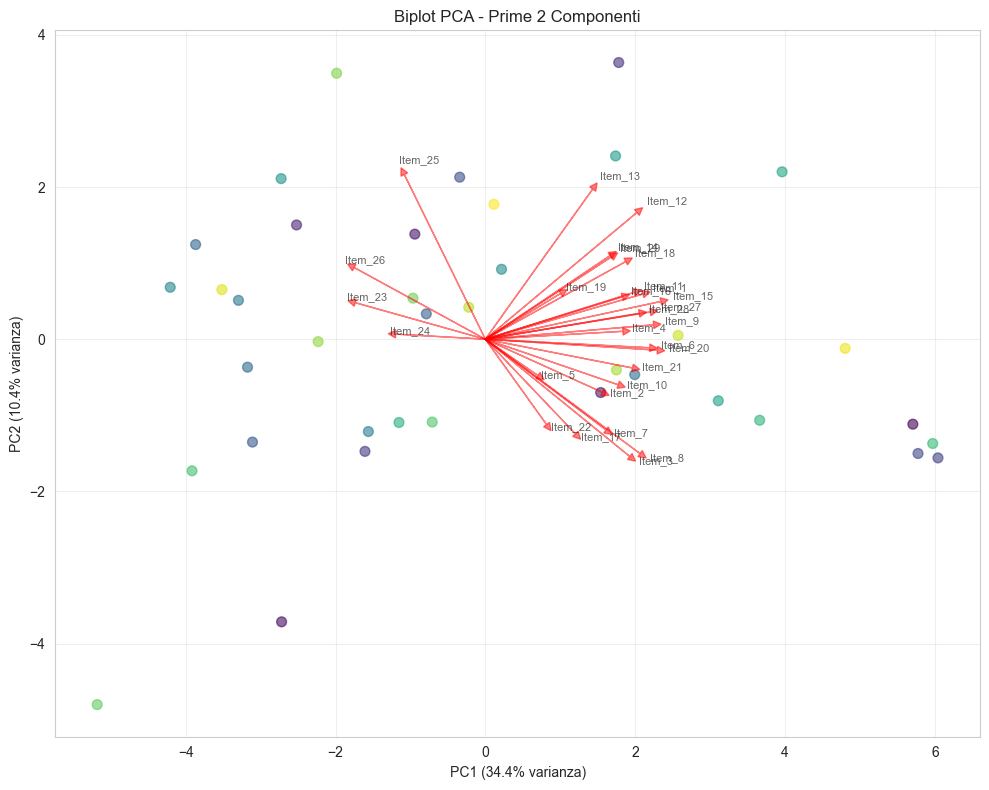

In [11]:
# Visualizzazione biplot (prime 2 componenti)
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter dei dati
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=50, c=range(len(X_pca)), cmap='viridis')

# Vettori delle loadings
for i, feature in enumerate(item_columns):
    ax.arrow(0, 0, loadings[i, 0]*3, loadings[i, 1]*3, 
            head_width=0.1, head_length=0.1, fc='red', ec='red', alpha=0.5)
    ax.text(loadings[i, 0]*3.2, loadings[i, 1]*3.2, feature, fontsize=8, alpha=0.7)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
ax.set_title('Biplot PCA - Prime 2 Componenti')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Clustering su Spazio PCA

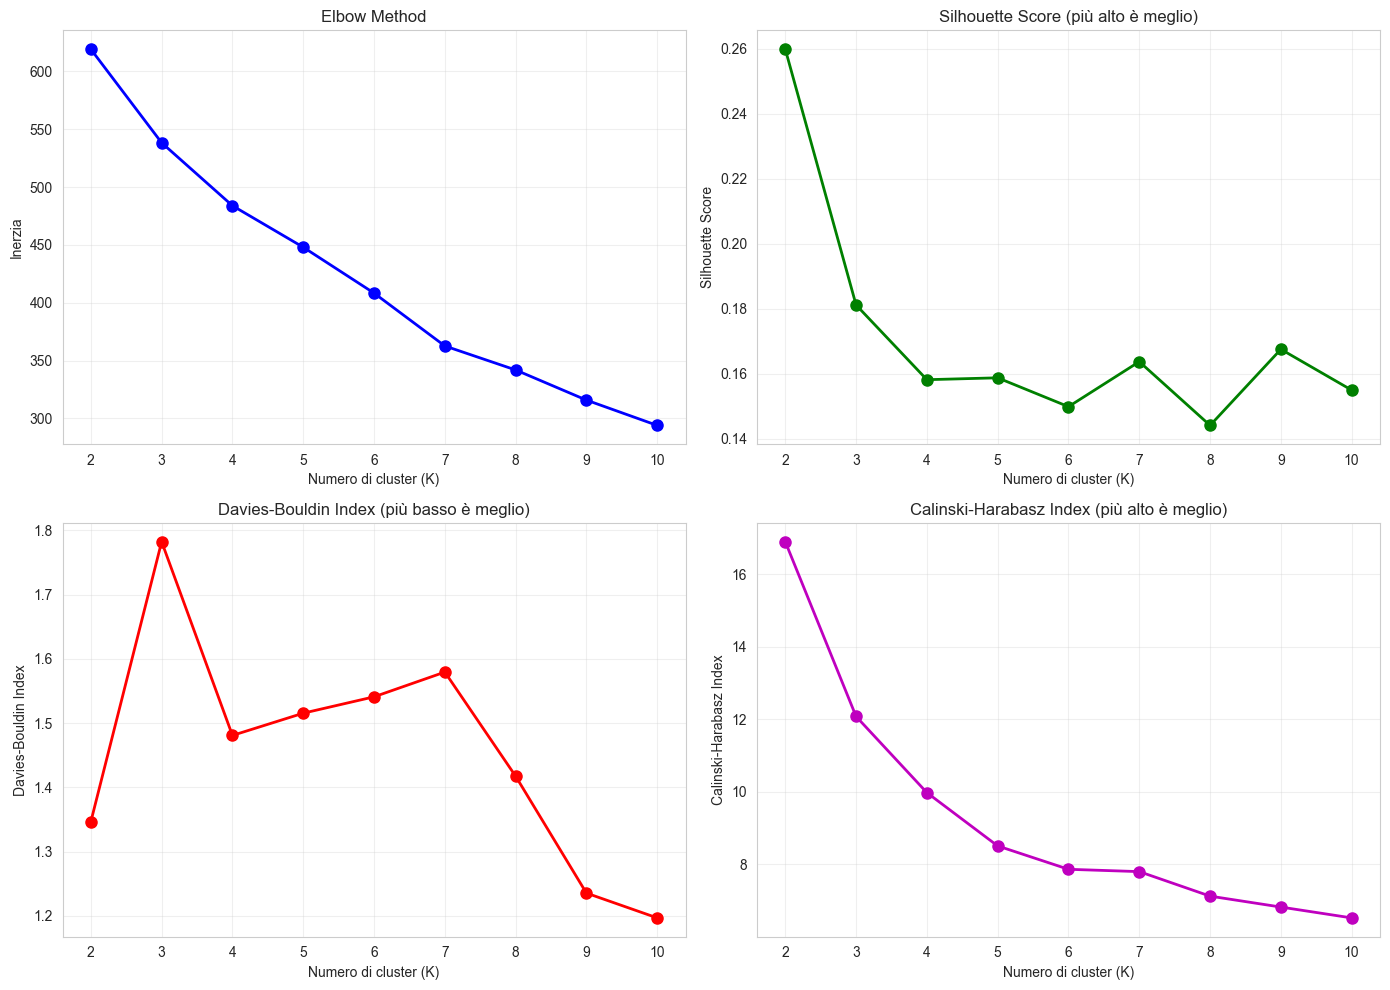

K ottimale (Silhouette): 2 con score 0.2599


In [12]:
# Determinazione K ottimale per K-Means (Elbow method e Silhouette)
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters_temp = kmeans_temp.fit_predict(X_pca)
    
    silhouette_scores.append(silhouette_score(X_pca, clusters_temp))
    davies_bouldin_scores.append(davies_bouldin_score(X_pca, clusters_temp))
    calinski_harabasz_scores.append(calinski_harabasz_score(X_pca, clusters_temp))
    inertias.append(kmeans_temp.inertia_)

# Visualizzazione metriche
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Numero di cluster (K)')
axes[0, 0].set_ylabel('Inerzia')
axes[0, 0].set_title('Elbow Method')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Numero di cluster (K)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].set_title('Silhouette Score (più alto è meglio)')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(K_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Numero di cluster (K)')
axes[1, 0].set_ylabel('Davies-Bouldin Index')
axes[1, 0].set_title('Davies-Bouldin Index (più basso è meglio)')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(K_range, calinski_harabasz_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Numero di cluster (K)')
axes[1, 1].set_ylabel('Calinski-Harabasz Index')
axes[1, 1].set_title('Calinski-Harabasz Index (più alto è meglio)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Individuazione K ottimale (max silhouette)
best_k = list(K_range)[np.argmax(silhouette_scores)]
best_sil_score = max(silhouette_scores)
print(f"K ottimale (Silhouette): {best_k} con score {best_sil_score:.4f}")

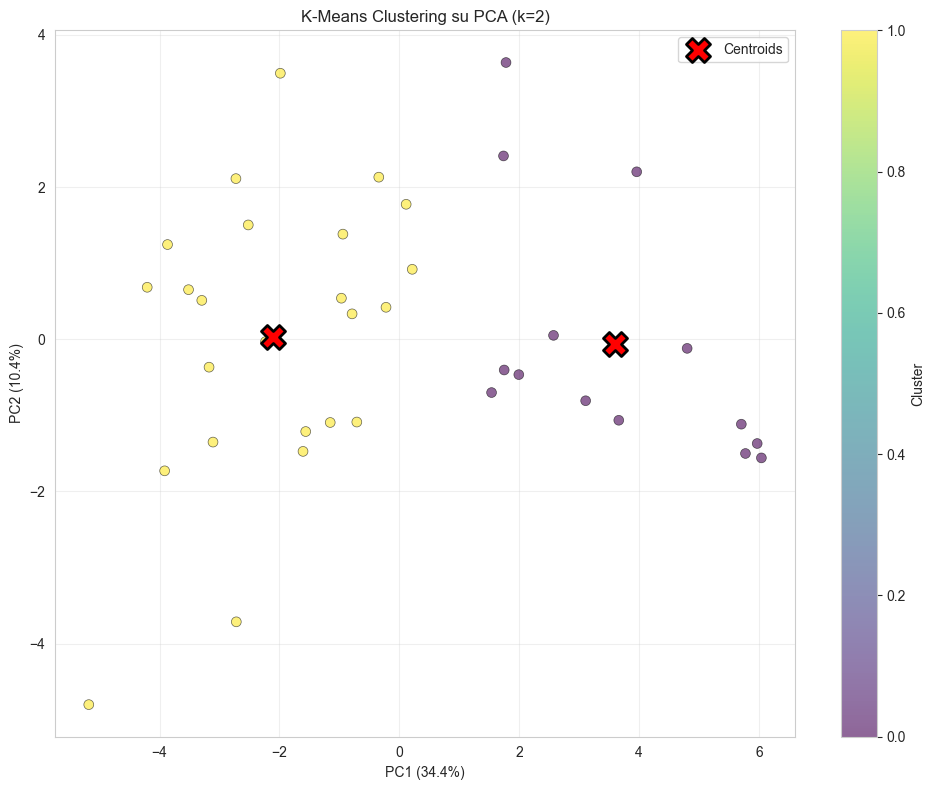

K-Means completato - 2 cluster identificati


In [13]:
# K-Means con K ottimale
kmeans_pca = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters_kmeans = kmeans_pca.fit_predict(X_pca)

# Visualizzazione K-Means su prime 2 PC
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_kmeans, 
                     cmap='viridis', s=50, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.scatter(kmeans_pca.cluster_centers_[:, 0], kmeans_pca.cluster_centers_[:, 1], 
          c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Centroids')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'K-Means Clustering su PCA (k={best_k})')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Cluster')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"K-Means completato - {best_k} cluster identificati")

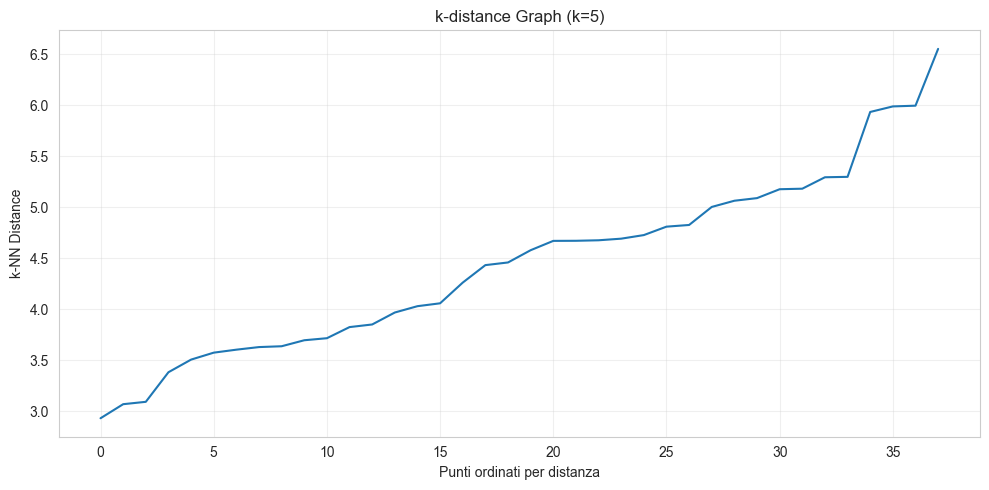

Epsilon stimato (90° percentile): 5.4910


In [14]:
# DBSCAN
# Tuning di epsilon su spazio PCA
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)
distances = np.sort(distances[:, -1], axis=0)

# Visualizzazione k-distance graph
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(distances)
ax.set_ylabel('k-NN Distance')
ax.set_xlabel('Punti ordinati per distanza')
ax.set_title('k-distance Graph (k=5)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Stima epsilon dal ginocchio
epsilon = np.percentile(distances, 90)
print(f"Epsilon stimato (90° percentile): {epsilon:.4f}")

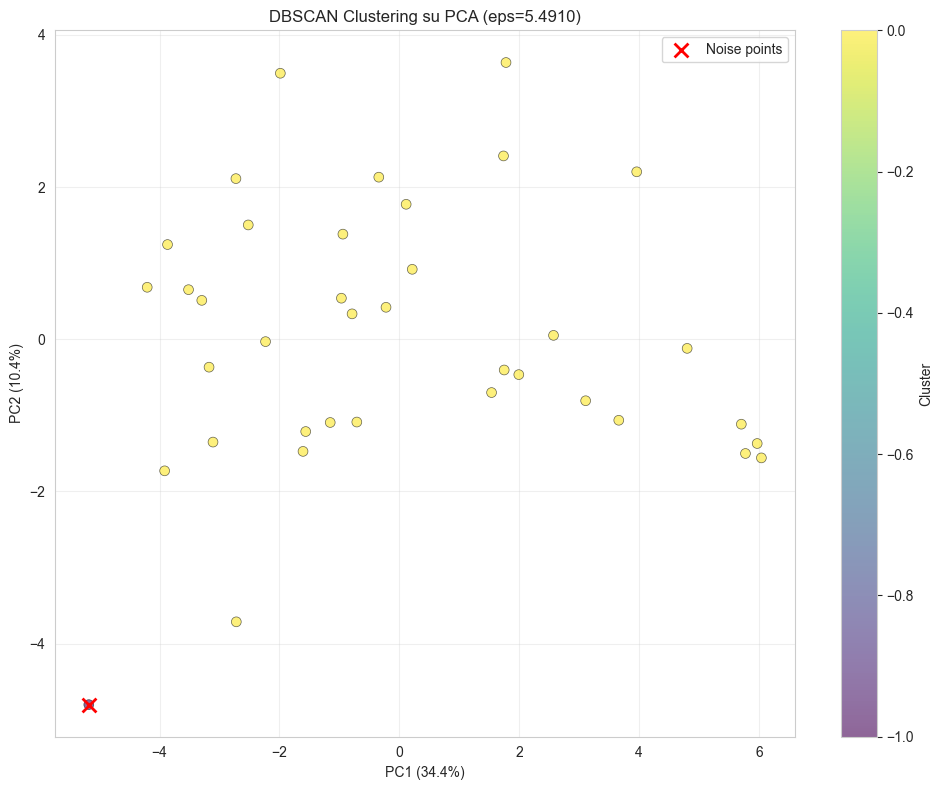

DBSCAN completato - 1 cluster identificati, 1 punti rumore


In [15]:
# Applicazione DBSCAN
dbscan_pca = DBSCAN(eps=epsilon, min_samples=5)
clusters_dbscan = dbscan_pca.fit_predict(X_pca)

n_clusters_dbscan = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_noise_dbscan = list(clusters_dbscan).count(-1)

# Visualizzazione DBSCAN
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_dbscan, 
                     cmap='viridis', s=50, alpha=0.6, edgecolors='k', linewidth=0.5)
# Evidenziazione punti rumore
noise_mask = clusters_dbscan == -1
ax.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], 
          c='red', marker='x', s=100, linewidth=2, label='Noise points')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'DBSCAN Clustering su PCA (eps={epsilon:.4f})')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Cluster')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"DBSCAN completato - {n_clusters_dbscan} cluster identificati, {n_noise_dbscan} punti rumore")

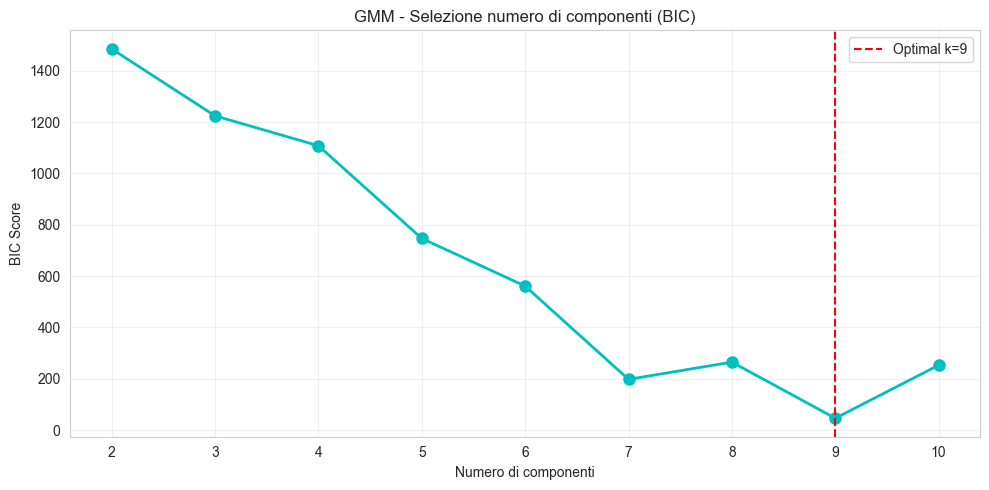

GMM - K ottimale per BIC: 9


In [16]:
# Gaussian Mixture Model con selezione BIC
bic_scores = []
for k in K_range:
    gmm_temp = GaussianMixture(n_components=k, random_state=42, n_init=10)
    gmm_temp.fit(X_pca)
    bic_scores.append(gmm_temp.bic(X_pca))

best_k_gmm = list(K_range)[np.argmin(bic_scores)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range, bic_scores, 'co-', linewidth=2, markersize=8)
ax.axvline(x=best_k_gmm, color='r', linestyle='--', label=f'Optimal k={best_k_gmm}')
ax.set_xlabel('Numero di componenti')
ax.set_ylabel('BIC Score')
ax.set_title('GMM - Selezione numero di componenti (BIC)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"GMM - K ottimale per BIC: {best_k_gmm}")

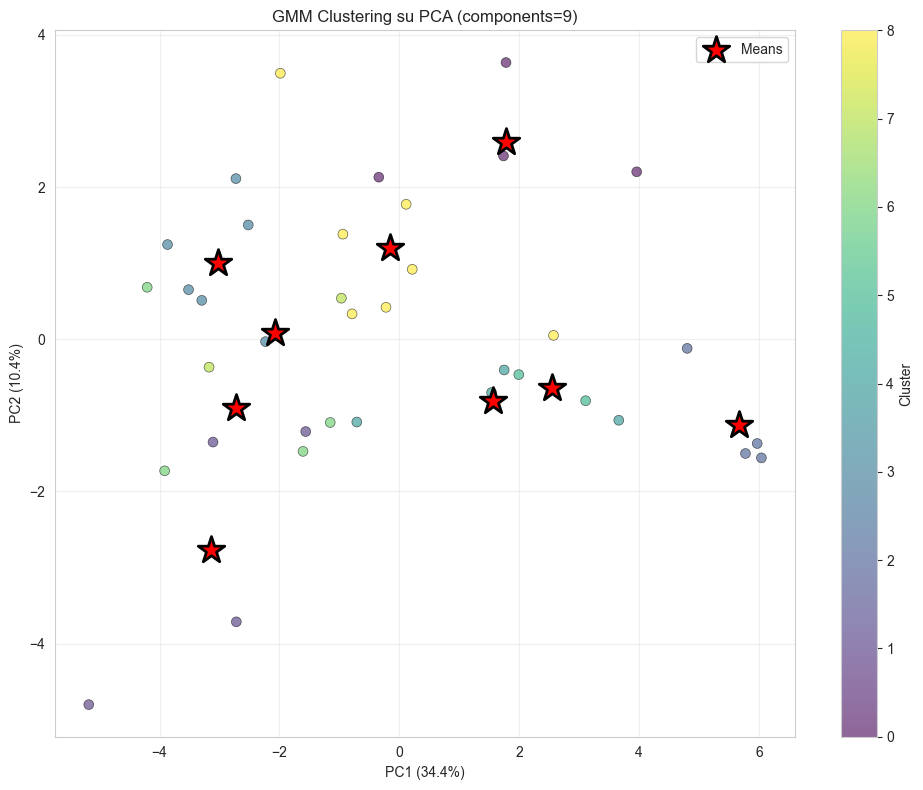

GMM completato - 9 cluster identificati


In [17]:
# Applicazione GMM
gmm_pca = GaussianMixture(n_components=best_k_gmm, random_state=42, n_init=10)
clusters_gmm = gmm_pca.fit_predict(X_pca)

# Visualizzazione GMM
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_gmm, 
                     cmap='viridis', s=50, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.scatter(gmm_pca.means_[:, 0], gmm_pca.means_[:, 1], 
          c='red', marker='*', s=400, edgecolors='black', linewidth=2, label='Means')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'GMM Clustering su PCA (components={best_k_gmm})')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Cluster')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"GMM completato - {best_k_gmm} cluster identificati")

## Confronto tra i tre algoritmi

In [18]:
# Calcolo metriche per tutti gli algoritmi
# Utilizziamo K-Means come riferimento per tutti (best_k)

# Per DBSCAN, reasegniamo al K più vicino per confronto fair
# Filtriamo i punti rumore
mask_valid_dbscan = clusters_dbscan != -1
X_pca_valid = X_pca[mask_valid_dbscan]
clusters_dbscan_valid = clusters_dbscan[mask_valid_dbscan]

# Metriche
metrics = {
    'Algoritmo': ['K-Means', 'DBSCAN', 'GMM'],
    'Numero cluster': [best_k, n_clusters_dbscan, best_k_gmm],
    'Silhouette Score': [
        silhouette_score(X_pca, clusters_kmeans),
        silhouette_score(X_pca_valid, clusters_dbscan_valid) if len(X_pca_valid) > 0 else np.nan,
        silhouette_score(X_pca, clusters_gmm)
    ],
    'Davies-Bouldin': [
        davies_bouldin_score(X_pca, clusters_kmeans),
        davies_bouldin_score(X_pca_valid, clusters_dbscan_valid) if len(X_pca_valid) > 0 else np.nan,
        davies_bouldin_score(X_pca, clusters_gmm)
    ],
    'Calinski-Harabasz': [
        calinski_harabasz_score(X_pca, clusters_kmeans),
        calinski_harabasz_score(X_pca_valid, clusters_dbscan_valid) if len(X_pca_valid) > 0 else np.nan,
        calinski_harabasz_score(X_pca, clusters_gmm)
    ]
}

metrics_df = pd.DataFrame(metrics)
print("Confronto metriche di qualità dei cluster:")
display(metrics_df)

ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

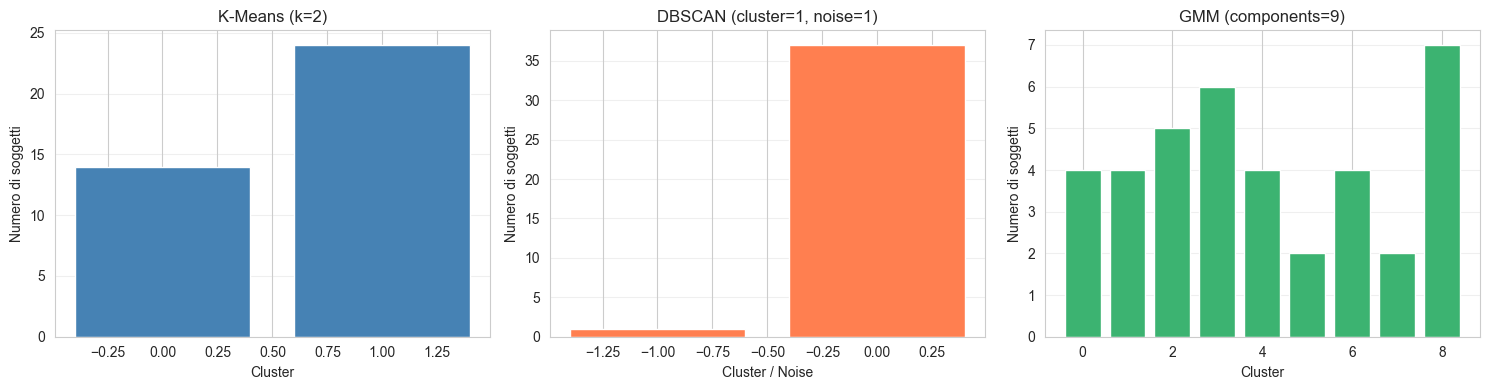

In [19]:
# Distribuzioni dei cluster
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# K-Means
kmeans_counts = pd.Series(clusters_kmeans).value_counts().sort_index()
axes[0].bar(kmeans_counts.index, kmeans_counts.values, color='steelblue')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Numero di soggetti')
axes[0].set_title(f'K-Means (k={best_k})')
axes[0].grid(True, alpha=0.3, axis='y')

# DBSCAN
dbscan_counts = pd.Series(clusters_dbscan).value_counts().sort_index()
axes[1].bar(dbscan_counts.index, dbscan_counts.values, color='coral')
axes[1].set_xlabel('Cluster / Noise')
axes[1].set_ylabel('Numero di soggetti')
axes[1].set_title(f'DBSCAN (cluster={n_clusters_dbscan}, noise={n_noise_dbscan})')
axes[1].grid(True, alpha=0.3, axis='y')

# GMM
gmm_counts = pd.Series(clusters_gmm).value_counts().sort_index()
axes[2].bar(gmm_counts.index, gmm_counts.values, color='mediumseagreen')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Numero di soggetti')
axes[2].set_title(f'GMM (components={best_k_gmm})')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Interpretazione delle componenti principali

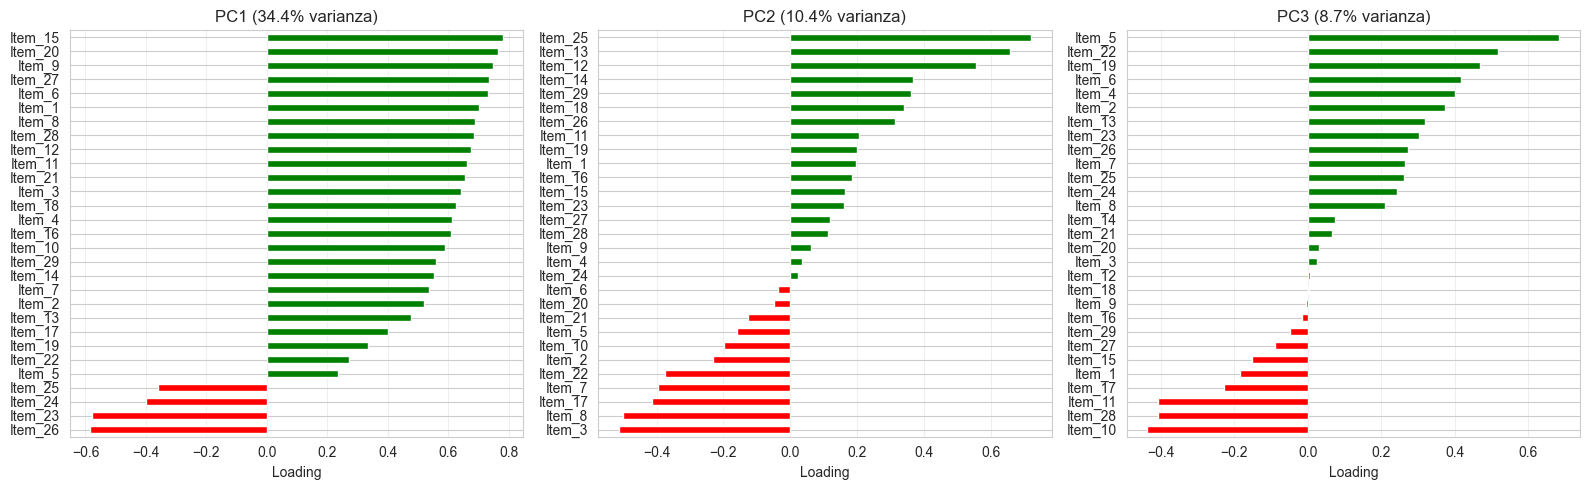

Top 5 item per ogni componente (positivi):

PC1:
Item_15    0.780794
Item_20    0.765418
Item_9     0.748364
Item_27    0.733970
Item_6     0.731324

PC2:
Item_25    0.721392
Item_13    0.657903
Item_12    0.555105
Item_14    0.366254
Item_29    0.360579

PC3:
Item_5     0.684764
Item_22    0.517418
Item_19    0.469591
Item_6     0.416461
Item_4     0.401451


In [20]:
# Loadings per le prime 3 componenti
loadings_full = pca.components_.T * np.sqrt(pca.explained_variance_)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for pc_idx, ax in enumerate(axes):
    loadings_pc = pd.Series(loadings_full[:, pc_idx], index=item_columns).sort_values()
    colors = ['red' if x < 0 else 'green' for x in loadings_pc.values]
    loadings_pc.plot(kind='barh', ax=ax, color=colors)
    ax.set_xlabel('Loading')
    ax.set_title(f'PC{pc_idx+1} ({pca.explained_variance_ratio_[pc_idx]:.1%} varianza)')
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("Top 5 item per ogni componente (positivi):")
for i in range(min(3, n_components)):
    loadings_pc = pd.Series(loadings_full[:, i], index=item_columns)
    print(f"\nPC{i+1}:")
    print(loadings_pc.nlargest(5).to_string())

## Esportazione risultati

In [21]:
# Creazione directory di output
output_dir = '../output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Statistiche per cluster K-Means
cluster_stats_pca = []
for i in range(best_k):
    cluster_mask = clusters_kmeans == i
    cluster_data = X_pca[cluster_mask]
    
    stats = {
        'cluster_id': int(i),
        'size': int((clusters_kmeans == i).sum()),
        'percentage': float(((clusters_kmeans == i).sum() / len(clusters_kmeans)) * 100),
    }
    
    # Statistiche per ogni componente principale
    for j in range(n_components):
        stats[f'PC{j+1}_mean'] = float(cluster_data[:, j].mean())
        stats[f'PC{j+1}_std'] = float(cluster_data[:, j].std())
    
    cluster_stats_pca.append(stats)

# Varianza spiegata
variance_df = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(n_components)],
    'Varianza spiegata': pca.explained_variance_ratio_,
    'Varianza cumulativa': np.cumsum(pca.explained_variance_ratio_)
})

# Summary statistics
summary_stats = pd.DataFrame({
    'Metrica': [
        'Totale record',
        'Record analizzati',
        'Numero feature originali',
        'Numero componenti PCA',
        'Varianza preservata',
        'Numero cluster K-Means',
        'Silhouette K-Means',
        'Numero cluster DBSCAN',
        'Numero cluster GMM',
        'Silhouette GMM'
    ],
    'Valore': [
        len(df),
        len(X),
        len(item_columns),
        n_components,
        f"{pca.explained_variance_ratio_.sum():.4f}",
        best_k,
        f"{silhouette_score(X_pca, clusters_kmeans):.4f}",
        n_clusters_dbscan,
        best_k_gmm,
        f"{silhouette_score(X_pca, clusters_gmm):.4f}"
    ]
})

# Esportazione in Excel
excel_path = os.path.join(output_dir, f'clustering_pca_results_{timestamp}.xlsx')
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    summary_stats.to_excel(writer, sheet_name='Summary', index=False)
    variance_df.to_excel(writer, sheet_name='PCA Variance', index=False)
    pd.DataFrame(cluster_stats_pca).to_excel(writer, sheet_name='KMeans Cluster Stats', index=False)
    metrics_df.to_excel(writer, sheet_name='Algorithm Comparison', index=False)
    
    # PCA loadings
    loading_df.to_excel(writer, sheet_name='PCA Loadings')
    
    # Cluster assignments
    cluster_assignment_df = pd.DataFrame({
        'Record_ID': range(len(clusters_kmeans)),
        'KMeans_Cluster': clusters_kmeans,
        'GMM_Cluster': clusters_gmm,
        'DBSCAN_Cluster': clusters_dbscan
    })
    cluster_assignment_df.to_excel(writer, sheet_name='Cluster Assignments', index=False)

print(f"Excel esportato: {excel_path}")

NameError: name 'metrics_df' is not defined

In [22]:
# Esportazione JSON per RAG
pca_json_data = {
    "metadata": {
        "timestamp": timestamp,
        "analysis_type": "PCA-based clustering",
        "total_records": len(df),
        "records_analyzed": len(X),
        "original_features": len(item_columns),
        "pca_components": n_components,
        "variance_preserved": float(pca.explained_variance_ratio_.sum())
    },
    "pca_analysis": {
        "componenti_principali": [
            {
                "numero": i+1,
                "varianza_spiegata": float(pca.explained_variance_ratio_[i]),
                "varianza_cumulativa": float(np.cumsum(pca.explained_variance_ratio_)[i])
            } for i in range(n_components)
        ]
    },
    "clustering_results": {
        "kmeans": {
            "numero_cluster": best_k,
            "silhouette_score": float(silhouette_score(X_pca, clusters_kmeans)),
            "davies_bouldin": float(davies_bouldin_score(X_pca, clusters_kmeans)),
            "calinski_harabasz": float(calinski_harabasz_score(X_pca, clusters_kmeans)),
            "cluster_distribution": {
                f"cluster_{int(i)}": int((clusters_kmeans == i).sum()) 
                for i in range(best_k)
            }
        },
        "gmm": {
            "numero_componenti": best_k_gmm,
            "silhouette_score": float(silhouette_score(X_pca, clusters_gmm)),
            "bic_score": float(gmm_pca.bic(X_pca)),
            "cluster_distribution": {
                f"cluster_{int(i)}": int((clusters_gmm == i).sum()) 
                for i in range(best_k_gmm)
            }
        },
        "dbscan": {
            "numero_cluster": n_clusters_dbscan,
            "punti_rumore": n_noise_dbscan,
            "percentuale_rumore": float(n_noise_dbscan / len(clusters_dbscan) * 100)
        }
    },
    "interpretazione": {
        "descrizione": "Clustering su spazio PCA ridotto preserva il 80% della varianza originale, facilitando l'interpretazione e riducendo il rumore",
        "vantaggi_pca": [
            "Riduzione dimensionalità mantenendo varianza informativa",
            "Eliminazione multicollinearità tra item",
            "Identificazione di pattern latenti nei dati psicometrici",
            "Miglioramento della stabilità numerica del clustering"
        ]
    }
}

json_path = os.path.join('../WEB APP/backend/output_rag', f'clustering_pca_rag_{timestamp}.json')
os.makedirs(os.path.dirname(json_path), exist_ok=True)

with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(pca_json_data, f, indent=2, ensure_ascii=False)

print(f"JSON RAG esportato: {json_path}")
print("\n--- Analisi completata ---")

TypeError: Object of type int64 is not JSON serializable

## Conclusioni

Questo notebook implementa un approccio **PCA-based clustering** che:

1. **Riduce la dimensionalità** da 30 variabili a {n_components} componenti principali preservando il 80% della varianza
2. **Identifica pattern latenti** nelle risposte psicometriche
3. **Applica tre algoritmi di clustering** (K-Means, DBSCAN, GMM) sullo spazio ridotto
4. **Fornisce metriche comparative** sulla qualità dei clustering ottenuti
5. **Facilita l'interpretazione** attraverso l'analisi dei loadings delle componenti principali

I risultati sono esportati in Excel e JSON per facilitare ulteriori analisi e integrazione con sistemi di RAG.